In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/Fish dataset(Assignment).zip'
extract_path = '/content/data/'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete!")

Extraction complete!


In [16]:
data_train_dir = '/content/data/FishImgDataset/train'
data_val_dir = '/content/data/FishImgDataset/val'
data_test_dir = '/content/data/FishImgDataset/test'

In [17]:
batch_size = 32
img_height = 180
img_width = 180
# epochs = 274

In [19]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_train_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size
)



Found 8809 files belonging to 31 classes.


In [21]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_val_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size
)



Found 2751 files belonging to 31 classes.


In [22]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    data_test_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 1761 files belonging to 31 classes.


In [23]:
train_ds.class_names

['Bangus',
 'Big Head Carp',
 'Black Spotted Barb',
 'Catfish',
 'Climbing Perch',
 'Fourfinger Threadfin',
 'Freshwater Eel',
 'Glass Perchlet',
 'Goby',
 'Gold Fish',
 'Gourami',
 'Grass Carp',
 'Green Spotted Puffer',
 'Indian Carp',
 'Indo-Pacific Tarpon',
 'Jaguar Gapote',
 'Janitor Fish',
 'Knifefish',
 'Long-Snouted Pipefish',
 'Mosquito Fish',
 'Mudfish',
 'Mullet',
 'Pangasius',
 'Perch',
 'Scat Fish',
 'Silver Barb',
 'Silver Carp',
 'Silver Perch',
 'Snakehead',
 'Tenpounder',
 'Tilapia']

In [24]:
val_ds.class_names

['Bangus',
 'Big Head Carp',
 'Black Spotted Barb',
 'Catfish',
 'Climbing Perch',
 'Fourfinger Threadfin',
 'Freshwater Eel',
 'Glass Perchlet',
 'Goby',
 'Gold Fish',
 'Gourami',
 'Grass Carp',
 'Green Spotted Puffer',
 'Indian Carp',
 'Indo-Pacific Tarpon',
 'Jaguar Gapote',
 'Janitor Fish',
 'Knifefish',
 'Long-Snouted Pipefish',
 'Mosquito Fish',
 'Mudfish',
 'Mullet',
 'Pangasius',
 'Perch',
 'Scat Fish',
 'Silver Barb',
 'Silver Carp',
 'Silver Perch',
 'Snakehead',
 'Tenpounder',
 'Tilapia']

In [25]:
test_ds.class_names

['Bangus',
 'Big Head Carp',
 'Black Spotted Barb',
 'Catfish',
 'Climbing Perch',
 'Fourfinger Threadfin',
 'Freshwater Eel',
 'Glass Perchlet',
 'Goby',
 'Gold Fish',
 'Gourami',
 'Grass Carp',
 'Green Spotted Puffer',
 'Indian Carp',
 'Indo-Pacific Tarpon',
 'Jaguar Gapote',
 'Janitor Fish',
 'Knifefish',
 'Long-Snouted Pipefish',
 'Mosquito Fish',
 'Mudfish',
 'Mullet',
 'Pangasius',
 'Perch',
 'Scat Fish',
 'Silver Barb',
 'Silver Carp',
 'Silver Perch',
 'Snakehead',
 'Tenpounder',
 'Tilapia']

# Normalize Data

In [26]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

# Optimize Performance (Optional but Recommended)

In [27]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Build CNN Model

In [29]:
num_classes = 31

model = Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')  # MULTI-CLASS
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Compile Model

In [30]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model (Uses Validation Set)

In [33]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 860s 3s/step - accuracy: 0.3345 - loss: 2.3859 - val_accuracy: 0.4522 - val_loss: 1.9867
Epoch 2/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 842s 3s/step - accuracy: 0.3931 - loss: 2.1222 - val_accuracy: 0.5329 - val_loss: 1.6605
Epoch 3/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 846s 3s/step - accuracy: 0.4540 - loss: 1.8901 - val_accuracy: 0.6187 - val_loss: 1.4119
Epoch 4/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 846s 3s/step - accuracy: 0.4999 - loss: 1.6981 - val_accuracy: 0.6612 - val_loss: 1.1970
Epoch 5/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 869s 3s/step - accuracy: 0.5507 - loss: 1.5111 - val_accuracy: 0.7230 - val_loss: 1.0265
Epoch 6/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 850s 3s/step - accuracy: 0.5841 - loss: 1.3470 - val_accuracy: 0.7735 - val_loss: 0.8875
Epoch 7/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 868s 3s/step - accuracy: 0.6216 - loss: 1.2194 - val_accuracy: 0.8019 - val_loss: 0.8095
Epoch 8/15
276/276 ━━━━━━━━━━━━━━━━━━━━ 847s 3s/step - accuracy: 0.6540 - loss: 1.1113 - val_accu

# Evaluate on Test Set

In [34]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

56/56 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.9074 - loss: 0.4716
Test Accuracy: 0.9074389338493347


# Plot Accuracy

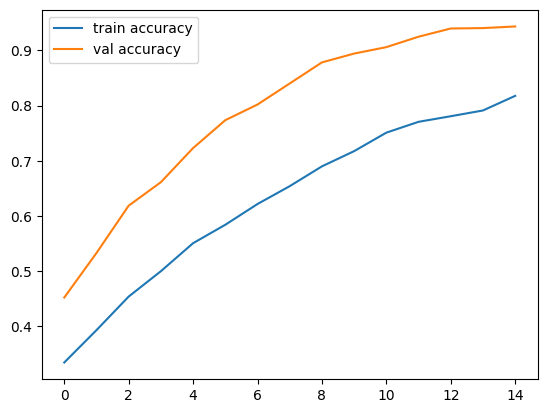

In [35]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.show()

# Validate a single fish image

## Load image

In [38]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

img_path = "/content/SilverCarp.jpg"

img = load_img(img_path, target_size=(img_height, img_width))

## convert to array

In [39]:
img_array = img_to_array(img)

## Normalize (VERY IMPORTANT)

Same preprocessing you used during training:

In [40]:
img_array = img_array / 255.0

## Add batch dimension

Model expects shape: (batch, height, width, channels)

In [41]:


img_array = np.expand_dims(img_array, axis=0)

##  Make prediction

In [42]:
predictions = model.predict(img_array)
predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step


array([[3.6757819e-17, 8.6520716e-14, 1.5717958e-22, 1.2497817e-18,
        5.7618730e-18, 8.0107565e-15, 3.8353877e-22, 2.3366830e-17,
        6.9778405e-14, 1.1409575e-15, 3.2514554e-20, 2.3924106e-06,
        5.6602124e-29, 2.1580032e-08, 3.0843477e-23, 9.3820155e-36,
        1.5454151e-23, 7.7329068e-21, 3.7551583e-20, 2.2888830e-18,
        1.6257231e-21, 1.3521170e-15, 2.9814579e-15, 7.2586327e-21,
        2.3124913e-33, 9.2315428e-17, 9.9999762e-01, 4.3507876e-16,
        2.6851831e-22, 2.2228896e-20, 2.2172464e-15]], dtype=float32)

## Get predicted class

In [45]:
train_ds_temp = tf.keras.utils.image_dataset_from_directory(data_train_dir)
class_names = train_ds_temp.class_names

Found 8809 files belonging to 31 classes.


In [46]:


predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]

confidence = np.max(predictions[0])

## Print result

In [47]:
print("Predicted Fish:", predicted_class)
print("Confidence:", confidence)

Predicted Fish: Silver Carp
Confidence: 0.9999976


# Using Pretrained Model

# Imports

In [51]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Load Dataset

In [50]:
img_height = 224
img_width = 224
batch_size = 32

pretrained_train_ds = tf.keras.utils.image_dataset_from_directory(
    data_train_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

pretrained_val_ds = tf.keras.utils.image_dataset_from_directory(
    data_val_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

pretrained_test_ds = tf.keras.utils.image_dataset_from_directory(
    data_test_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# SAVE CLASS NAMES ✅
class_names = train_ds.class_names
num_classes = len(class_names)

Found 8809 files belonging to 31 classes.
Found 2751 files belonging to 31 classes.
Found 1761 files belonging to 31 classes.


## Preprocessing

MobileNetV2 needs [-1, 1] scaling

In [54]:
pretrained_train_ds = pretrained_train_ds.map(lambda x, y: (preprocess_input(x), y))
pretrained_val_ds = pretrained_val_ds.map(lambda x, y: (preprocess_input(x), y))
pretrained_test_ds = pretrained_test_ds.map(lambda x, y: (preprocess_input(x), y))

## Performance Optimization

In [55]:
AUTOTUNE = tf.data.AUTOTUNE

pretrained_train_ds = pretrained_train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
pretrained_val_ds = pretrained_val_ds.prefetch(buffer_size=AUTOTUNE)
pretrained_test_ds = pretrained_test_ds.prefetch(buffer_size=AUTOTUNE)

## Load Pretrained Model

In [56]:
base_model = MobileNetV2(
    weights='imagenet',
    input_shape=(img_height, img_width, 3),
    include_top=False
)

# Freeze base model
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


## Build Custom Classifier

In [57]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs=base_model.input, outputs=outputs)

# Compile Model

In [58]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Train Model

In [59]:
history = model.fit(
    pretrained_train_ds,
    validation_data=pretrained_val_ds,
    epochs=10
)

Epoch 1/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 657s 2s/step - accuracy: 0.5566 - loss: 1.6486 - val_accuracy: 0.8575 - val_loss: 0.5418
Epoch 2/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 690s 2s/step - accuracy: 0.7554 - loss: 0.8171 - val_accuracy: 0.9153 - val_loss: 0.3169
Epoch 3/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 593s 2s/step - accuracy: 0.8187 - loss: 0.6028 - val_accuracy: 0.9353 - val_loss: 0.2298
Epoch 4/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 615s 2s/step - accuracy: 0.8402 - loss: 0.5066 - val_accuracy: 0.9546 - val_loss: 0.1767
Epoch 5/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 610s 2s/step - accuracy: 0.8674 - loss: 0.4208 - val_accuracy: 0.9615 - val_loss: 0.1480
Epoch 6/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 665s 2s/step - accuracy: 0.8781 - loss: 0.3757 - val_accuracy: 0.9684 - val_loss: 0.1260
Epoch 7/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 604s 2s/step - accuracy: 0.8886 - loss: 0.3473 - val_accuracy: 0.9767 - val_loss: 0.1067
Epoch 8/10
276/276 ━━━━━━━━━━━━━━━━━━━━ 622s 2s/step - accuracy: 0.9046 - loss: 0.2977 - val_accu

## Fine-Tuning Step

After initial training, unfreeze part of the model:

In [60]:
base_model.trainable = True

# Freeze first layers, train deeper ones
for layer in base_model.layers[:100]:
    layer.trainable = False

## Recompile

In [61]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Continue Training

In [62]:
history_fine = model.fit(
    pretrained_train_ds,
    validation_data=pretrained_val_ds,
    epochs=5
)

Epoch 1/5
276/276 ━━━━━━━━━━━━━━━━━━━━ 1003s 3s/step - accuracy: 0.7550 - loss: 0.8550 - val_accuracy: 0.9578 - val_loss: 0.1411
Epoch 2/5
276/276 ━━━━━━━━━━━━━━━━━━━━ 909s 3s/step - accuracy: 0.8141 - loss: 0.6121 - val_accuracy: 0.9702 - val_loss: 0.1119
Epoch 3/5
276/276 ━━━━━━━━━━━━━━━━━━━━ 922s 3s/step - accuracy: 0.8519 - loss: 0.4757 - val_accuracy: 0.9782 - val_loss: 0.0944
Epoch 4/5
276/276 ━━━━━━━━━━━━━━━━━━━━ 934s 3s/step - accuracy: 0.8759 - loss: 0.3916 - val_accuracy: 0.9811 - val_loss: 0.0817
Epoch 5/5
276/276 ━━━━━━━━━━━━━━━━━━━━ 970s 3s/step - accuracy: 0.8902 - loss: 0.3282 - val_accuracy: 0.9833 - val_loss: 0.0747


## Evaluate

In [63]:
pretrained_test_loss, pretrained_test_acc = model.evaluate(pretrained_test_ds)
print("Test Accuracy:", pretrained_test_acc)

56/56 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.9682 - loss: 0.1223
Test Accuracy: 0.9681999087333679


## Predicting for single image

# Import

In [64]:
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import numpy as np
import matplotlib.pyplot as plt

## Load & preprocess image

In [66]:
img_path = "/content/SilverCarp.jpg"

img = load_img(img_path, target_size=(224, 224))  # MUST match training size
img_array = img_to_array(img)

# IMPORTANT: use preprocess_input (NOT /255)
img_array = preprocess_input(img_array)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

## Predict

In [67]:
predictions = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


## Get class

In [68]:
predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]
confidence = np.max(predictions[0])

##  Show result

Predicted Fish: Silver Carp
Confidence: 0.9999318


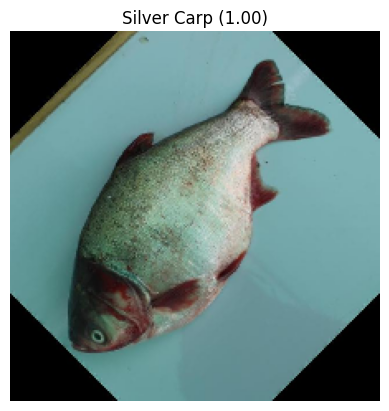

In [69]:
print("Predicted Fish:", predicted_class)
print("Confidence:", confidence)
# display image
plt.imshow(img)
plt.title(f"{predicted_class} ({confidence:.2f})")
plt.axis('off')
plt.show()